# PyTorch Hands-On Playground

A practical, experiment-first bridge from your NumPy MNIST-from-scratch work to CNNs, embeddings, and transformers. Run small pieces, predict outcomes before execution, and treat the blank cells as your laboratory.

## Curated route
1. Tensor fluency: shape, dtype, device, indexing, reshaping, broadcasting, reductions, matrix multiplication.
2. Autograd: computation graphs and gradients.
3. Modules: parameters, activations, losses, optimizers.
4. Training: Dataset/DataLoader, evaluation, debugging, checkpoints.
5. Transformer runway: embeddings, dot products, softmax, masking.

## Setup with uv
```bash
uv venv
uv pip install torch jupyterlab matplotlib
uv run jupyter lab
```
No downloads are needed: all data below is synthetic.

In [11]:
import random
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
print('PyTorch:', torch.__version__)

# Apple silicon first; CPU stays a reliable fallback.
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print('Using:', device)

PyTorch: 2.13.0
Using: mps


## 1 — Start with a tensor’s three facts

A tensor is like a NumPy array, but it can run on accelerators and later record operations for automatic differentiation. For now, every tensor has three facts worth checking: **shape** (its axes and their sizes), **dtype** (what kind of numbers it holds), and **device** (where it lives).

Read shapes by naming their axes: `(batch, features)`, `(batch, channels, height, width)`, or `(batch, tokens, embedding_dim)`. The first goal is to make those names feel more useful than a bare list of numbers.

In [3]:
# NumPy interop: predict which tensor reflects the NumPy mutation.
array = np.array([1, 2, 3], dtype=np.float32)
shared = torch.from_numpy(array)
copy = torch.tensor(array)
array[0] = 99
print('shared:', shared, '| copy:', copy)
print(shared.dtype, shared.shape, shared.device)

shared: tensor([99.,  2.,  3.]) | copy: tensor([1., 2., 3.])
torch.float32 torch.Size([3]) cpu


`torch.from_numpy` and `torch.tensor` look similar, but their ownership differs: the first shares the NumPy array's memory, while the second copies it.

Reflection: model inputs usually use floating-point values. When could shared NumPy memory be helpful, and when could it surprise you?

## 2 — Create and inspect tensors

`shape`, `dtype`, and `device` are the first three facts to check when something goes wrong. `torch.zeros`, `torch.ones`, `torch.arange`, `torch.rand`, and `torch.randn` create tensors with different initial values; they all still have those same three facts.

In [4]:
zeros = torch.zeros(2, 3)
ids = torch.ones((2, 3), dtype=torch.int64)

# here, arange is just 'a range'. it's start inclusive, end not-inclusive 
# torch.range() is start and end inclusive, but arange is closer to python's range() so we use it 
steps = torch.arange(0, 12, 2, dtype=torch.float32)
noise = torch.randn(2, 3, device=device)
for name, t in {'zeros':zeros, 'ids':ids, 'steps':steps, 'noise':noise}.items():
    print(f'{name}: shape={tuple(t.shape)}, dtype={t.dtype}, device={t.device}\n{t}')

zeros: shape=(2, 3), dtype=torch.float32, device=cpu
tensor([[0., 0., 0.],
        [0., 0., 0.]])
ids: shape=(2, 3), dtype=torch.int64, device=cpu
tensor([[1, 1, 1],
        [1, 1, 1]])
steps: shape=(6,), dtype=torch.float32, device=cpu
tensor([ 0.,  2.,  4.,  6.,  8., 10.])
noise: shape=(2, 3), dtype=torch.float32, device=mps:0
tensor([[-1.1506, -0.0281,  0.2427],
        [ 0.1178, -1.0100,  0.7729]], device='mps:0')


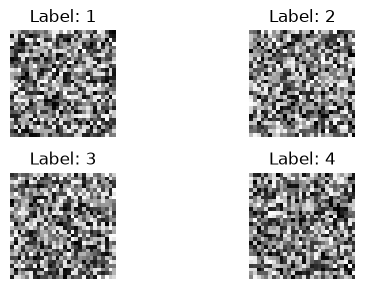

In [5]:
# Images: axes are (batch=4, channels=1, height=28, width=28).
# Labels are integer class IDs, shape (batch=4,).
# Your turn: change these values, then predict the shape of image_batch[i].
image_batch = torch.rand(4, 1, 28, 28)
labels = torch.tensor([1, 2, 3, 4])

from matplotlib import pyplot as plt

plt.figure(figsize=(6, 3))
for i in range(4):
    plt.subplot(2, 2, i + 1)
    plt.imshow(image_batch[i].squeeze(), cmap="gray")
    plt.title(f"Label: {labels[i]}")
    plt.axis("off")
plt.tight_layout()

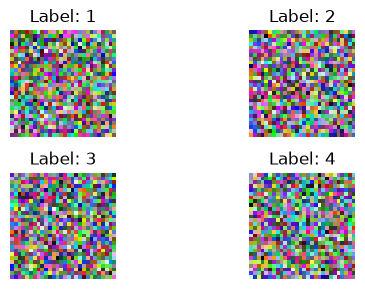

In [6]:
# Your experiment, extended: color images use three channels (red, green, blue).
# PyTorch vision convention: (batch, channels, height, width) = (4, 3, 28, 28).
# Matplotlib expects one image as (height, width, channels), so permute axes 1, 2, 0.
color_image_batch = torch.rand(4, 3, 28, 28)

plt.figure(figsize=(6, 3))
for i in range(4):
    plt.subplot(2, 2, i + 1)
    image = color_image_batch[i].permute(1, 2, 0)
    plt.imshow(image)
    plt.title(f"Label: {labels[i]}")
    plt.axis("off")
plt.tight_layout()

## 3 — Navigate and reshape tensors

First index into an axis; then reshape without changing the underlying number of elements. `reshape` returns a tensor with a new shape—it does **not** mutate the variable you called it on. `flatten(start_dim=...)` is a convenient reshape that combines the named axis and everything after it.

`transpose` changes the order of two axes; `permute` can reorder any number of axes. They preserve the values but change the coordinate system used to find them. `view` is a lower-level reshape operation that needs compatible contiguous memory, so prefer `reshape` while learning.

In [7]:
# Start one-dimensional, then give the same 24 values three named axes.
x = torch.arange(24).reshape(2, 3, 4)  # (examples=2, rows=3, columns=4)
print('x:', x.shape, '\n', x)

# Indexing removes an axis when you choose one specific position on it.
print('first example:', x[0].shape, '\n', x[0])          # (rows=3, columns=4)
print('last column of first example:', x[0, :, -1].shape, x[0, :, -1])  # (rows=3,)
print('one scalar:', x[1, 2, 3].item())

# Predict before running: which axes remain after each flatten?
print('flatten from dim=2:', x.flatten(start_dim=2).shape)  # (2, 3, 4)
print('flatten from dim=1:', x.flatten(start_dim=1).shape)  # (2, 12)
print('flatten from dim=0:', x.flatten(start_dim=0).shape)  # (24,)

# Swap rows and columns: (2, 3, 4) -> (2, 4, 3).
print('swap axes:', x.transpose(1, 2).shape)

x.shape: torch.Size([24])
x: tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23])
x.shape: torch.Size([2, 3, 4])
x: tensor([[[ 0,  1,  2,  3],
         [ 4,  5,  6,  7],
         [ 8,  9, 10, 11]],

        [[12, 13, 14, 15],
         [16, 17, 18, 19],
         [20, 21, 22, 23]]])
first example: tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])
last column: tensor([ 3,  7, 11])
scalar: 23
flat per example: torch.Size([2, 3, 4])
flat per example: torch.Size([2, 12])
flat per example: torch.Size([24])
swap axes: torch.Size([2, 4, 3])


In [8]:
# Reshape returns a new tensor; it does not alter my_var by itself.
my_var = torch.arange(24).reshape(3, 2, 4)

print('original dim:', my_var.shape)

not_assigned = my_var.reshape(3, 8)
print('original is still:', my_var.shape)
print('returned reshape:', not_assigned.shape)

# Your turn: assign the returned tensor to my_var, then print its shape.
# my_var = my_var.reshape(3, 8)

# Reshape re-groups positions in order. Permute changes which axis is called channel/row/column.
# The same pixel can be addressed before and after changing (channel, height, width) -> (height, width, channel).
red_channel, row, col = 0, 1, 2

image = color_image_batch[0]
pixel_x = image[red_channel, row, col]
pixel_y = image.permute(1, 2, 0)[row, col, red_channel]

print(f'pixel_x: {pixel_x}, pixel_y: {pixel_y}')

original dim: torch.Size([3, 2, 4])
reshaped: tensor([[[ 0,  1,  2,  3],
         [ 4,  5,  6,  7]],

        [[ 8,  9, 10, 11],
         [12, 13, 14, 15]],

        [[16, 17, 18, 19],
         [20, 21, 22, 23]]])
pixel_x: 0.1569996476173401, pixel_y: 0.1569996476173401


## 4 — Combine and summarize tensors

These are three different operations that often appear together in neural-network code. Keep the shapes visible while reading them.

**Broadcasting** lets PyTorch reuse a smaller tensor along a compatible dimension. For example, a length-3 tensor can be added to every row of a `(2, 3)` tensor. PyTorch does not need to physically copy the values. This is how one bias value per output feature can be added to every example in a batch.

A **reduction** summarizes one dimension: `mean`, `sum`, and `max` are common examples. `mean(dim=1)` means "take the mean within each row" for a 2D tensor, so the column dimension is summarized and normally disappears. `keepdim=True` keeps it as size 1, which is useful when the result needs to broadcast back across the original columns.

Matrix multiplication, `@`, combines a shared dimension. For a dense layer, a batch of inputs `(batch, input_features)` multiplied by weights `(input_features, output_features)` produces `(batch, output_features)`. Each output is a weighted sum of the input features.

In [9]:
# Before running: predict each printed shape.
scores = torch.tensor([[1., 2., 3.], [10., 20., 30.]])  # (rows=2, columns=3)
offset = torch.tensor([.1, .2, .3])                     # (columns=3,)

# offset is reused for each row: conceptually [[.1, .2, .3], [.1, .2, .3]].
shifted_scores = scores + offset
print('scores:', scores.shape, '\n', scores)
print('offset:', offset.shape, '\n', offset)
print('broadcast addition:', shifted_scores.shape, '\n', shifted_scores)

row_means = scores.mean(dim=1)                 # one mean per row: (2,)
column_means = scores.mean(dim=0)              # one mean per column: (3,)
row_means_as_column = scores.mean(dim=1, keepdim=True)  # (2, 1)
print('mean within each row:', row_means.shape, row_means)
print('mean within each column:', column_means.shape, column_means)
print('row means with keepdim:', row_means_as_column.shape, row_means_as_column)
print('scores centered by their row means:', (scores - row_means_as_column).shape)

# Dense-layer-shaped multiplication: 3 examples, 4 input features, 2 output features.
features = torch.randn(3, 4)  # (batch=3, input_features=4)
weights = torch.randn(4, 2)   # (input_features=4, output_features=2)
outputs = features @ weights  # (batch=3, output_features=2)
print('dense layer:', features.shape, '@', weights.shape, '=', outputs.shape)

tensor([[ 1.1000,  2.2000,  3.3000],
        [10.1000, 20.2000, 30.3000]])
mean dim=1: tensor([ 2., 20.]) torch.Size([2])
mean dim=0: tensor([ 5.5000, 11.0000, 16.5000]) torch.Size([3])
keepdim: torch.Size([2, 1])
torch.Size([3, 4]) @ torch.Size([4, 2]) = torch.Size([3, 2])


In [ ]:
# Your turn: calculate one squared length per row. Expected tensor([25., 169.]), shape (2,).
vectors = torch.tensor([[3., 4.], [5., 12.]])  # (rows=2, coordinates=2)
# Hint: square every coordinate, then sum within each row: .sum(dim=1)
# squared_lengths =

# Creative: make a 2D temperature field, broadcast-add a 1D trend, find the warmest position.

### Randomness and reproducibility

Seed once at the beginning of a run. Re-seeding before every training step removes useful randomness.

In [ ]:
SEED = 7
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
a = torch.randn(3)
torch.manual_seed(SEED); b = torch.randn(3)
print(a, b, 'same?', torch.equal(a, b))

## 3 — Autograd and computation graphs

With `requires_grad=True`, PyTorch remembers differentiable operations. Call `backward()` on a scalar; its derivatives accumulate in `.grad`.

In [ ]:
# Predict df/dw for f = sum((3w + 1)^2) at w=[2,-1].
w = torch.tensor([2., -1.], requires_grad=True)
f = ((3*w + 1)**2).sum()
f.backward()
print('f:', f.item(), '| df/dw:', w.grad, '| grad_fn:', f.grad_fn)
# Gradients accumulate:
w = torch.tensor(2., requires_grad=True)
(w**2).backward(); print('first:', w.grad.item())
(w**2).backward(); print('second:', w.grad.item())
w.grad.zero_(); print('cleared:', w.grad.item())

In [ ]:
# Intentionally breakable: vector outputs need a reduction or gradient seed.
x = torch.tensor([1., 2.], requires_grad=True)
y = x**2
# y.backward()
y.sum().backward(); print(x.grad)
# Your turn: invent a scalar function and check your predicted gradient.

In [ ]:
x = torch.tensor(3., requires_grad=True); y = x**2
with torch.no_grad(): z = y * 10
print(y.requires_grad, z.requires_grad, y.detach().requires_grad)

## 4 — Parameters, modules, activations, losses, optimizers

`nn.Module` packages computation plus learnable parameters. An optimizer updates those parameters using gradients. `CrossEntropyLoss` takes raw logits `(batch, classes)` and integer class IDs—no softmax beforehand.

In [ ]:
class TinyRegressor(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(1, 8), nn.ReLU(), nn.Linear(8, 1))
    def forward(self, x): return self.net(x)
model = TinyRegressor()
print(model)
for name, p in model.named_parameters(): print(name, tuple(p.shape), p.requires_grad)

In [ ]:
logits = torch.tensor([[2., -1., .5], [.1, .2, .3]])
targets = torch.tensor([0, 2])
print('CE:', nn.CrossEntropyLoss()(logits, targets).item())
print('probabilities (inspection only):', logits.softmax(dim=1))
# Compare binary labels: nn.BCEWithLogitsLoss() takes one raw logit/example.

## 5 — Minimal training and evaluation loop

We fit `y ≈ 3x - 0.5` using synthetic, noisy data. The repeating rhythm is: forward → loss → clear old gradients → backward → optimizer step.

In [ ]:
torch.manual_seed(7)
x_all = torch.linspace(-2, 2, 160).unsqueeze(1)
y_all = 3*x_all - .5 + .35*torch.randn_like(x_all)
train_x, test_x = x_all[:128], x_all[128:]
train_y, test_y = y_all[:128], y_all[128:]
train_loader = DataLoader(TensorDataset(train_x, train_y), batch_size=16, shuffle=True)
bx, by = next(iter(train_loader)); print(bx.shape, by.shape)

In [ ]:
model = nn.Linear(1, 1).to(device)
loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=.08)
for epoch in range(80):
    model.train()
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        predictions = model(batch_x)
        loss = loss_fn(predictions, batch_y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    if epoch in {0, 1, 9, 79}: print(f'epoch {epoch+1:02d}: loss={loss.item():.4f}')
print('weight/bias:', model.weight.item(), model.bias.item())

In [ ]:
model.eval()
with torch.no_grad():
    test_predictions = model(test_x.to(device))
    test_loss = loss_fn(test_predictions, test_y.to(device))
print('test MSE:', test_loss.item())
# Your turn: change exactly one of lr, batch size, epochs, noise, or model. Observe stability and test error.

### Debug shapes and gradients

Early PyTorch failures usually involve shape, dtype, device, or missing gradient flow. Print the facts.

In [ ]:
def inspect(name, t):
    print(f'{name}: shape={tuple(t.shape)}, dtype={t.dtype}, device={t.device}, requires_grad={t.requires_grad}')
inspect('train_x', train_x); inspect('prediction', test_predictions)
optimizer.zero_grad(); loss_fn(model(train_x[:8].to(device)), train_y[:8].to(device)).backward()
for name, p in model.named_parameters():
    print(name, 'gradient norm:', None if p.grad is None else round(p.grad.norm().item(), 6))
# Breakable: nn.Linear(3, 2)(torch.randn(4, 5))
# Breakable: nn.CrossEntropyLoss()(torch.randn(4, 3), torch.tensor([0.,1.,2.,0.]))

### Save and load weights

Save `state_dict`, then recreate the same architecture and load it.

In [ ]:
from pathlib import Path
checkpoint_path = Path('tiny_regressor_state.pt')
torch.save(model.state_dict(), checkpoint_path)
restored = nn.Linear(1, 1).to(device)
restored.load_state_dict(torch.load(checkpoint_path, weights_only=True))
restored.eval()
with torch.no_grad(): print('same?', torch.allclose(model(test_x.to(device)), restored(test_x.to(device))))
print('saved:', checkpoint_path.resolve())

## 6 — Embeddings and attention: a short preview

An embedding maps token IDs to vectors. Transformer batches are commonly `(batch, tokens, embedding_dim)`. Attention scores every query against every key, normalizes across keys, then mixes values.

In [ ]:
embedding = nn.Embedding(num_embeddings=12, embedding_dim=4)
token_ids = torch.tensor([[2, 5, 1, 0], [4, 4, 7, 3]])
token_vectors = embedding(token_ids)
print('IDs:', token_ids.shape, '| embeddings:', token_vectors.shape)
# Creative: invent a tiny vocabulary. What task would make two IDs' vectors similar?

In [ ]:
torch.manual_seed(3)
B, T, D = 2, 4, 6
queries, keys, values = torch.randn(B,T,D), torch.randn(B,T,D), torch.randn(B,T,D)
scores = queries @ keys.transpose(-2, -1) / (D**.5)
weights = scores.softmax(dim=-1)
context = weights @ values
print('scores:', scores.shape, 'weights:', weights.shape, 'context:', context.shape)
print('each attention row sums to:', weights[0].sum(dim=-1))
mask = torch.triu(torch.ones(T,T,dtype=torch.bool), diagonal=1)
causal_weights = scores.masked_fill(mask, float('-inf')).softmax(dim=-1)
print('causal weights:', causal_weights[0].round(decimals=3))
# Predict: which entries are zero, and why does -inf cause that?

## Next moves

1. Trace shapes through `nn.Conv2d` using a toy `(N,1,28,28)` batch.
2. Build a two-layer MLP for synthetic classification.
3. Train an `nn.Embedding` table on a tiny next-token task.
4. Add learned Q, K, V projections to the attention cell.

Final reflection: identify the tensor operation that feels least intuitive and make a five-line example that makes it visible before moving on.